In [3]:
# Importing Libraries
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

Found cached dataset csv (C:/Users/theim/.cache/huggingface/datasets/lukebarousse___csv/lukebarousse--data_jobs-20095235c13fb98d/0.0.0/6954658bab30a358235fa864b05cf819af0e179325c740e4bc853bcc7ec513e1)


  0%|          | 0/1 [00:00<?, ?it/s]

In [4]:
# Only et the US Data Analyst job postings
df_US_DA = df[
    (df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')
].copy()

# Remove NaN values frrom column for plotting
df_US_DA = df_US_DA.dropna(subset=['salary_year_avg'])

In [5]:
# Explode Skills
df_US_DA = df_US_DA.explode('job_skills')

In [6]:
# Get top 10 skills ordered by count of skills
df_top_skills_count = df_US_DA.groupby('job_skills').agg(
    median_salary=('salary_year_avg', 'median'),
    skill_count=('salary_year_avg', 'size')
).sort_values(by='skill_count', ascending=False).head(10).sort_values(by='median_salary', ascending=False)

# Get top 10 skills based on median yearly salary
df_top_pay = df_US_DA.groupby('job_skills').agg(
    median_salary=('salary_year_avg', 'median'),
    skill_count=('salary_year_avg', 'size')
).sort_values(by='median_salary', ascending=False).head(10)

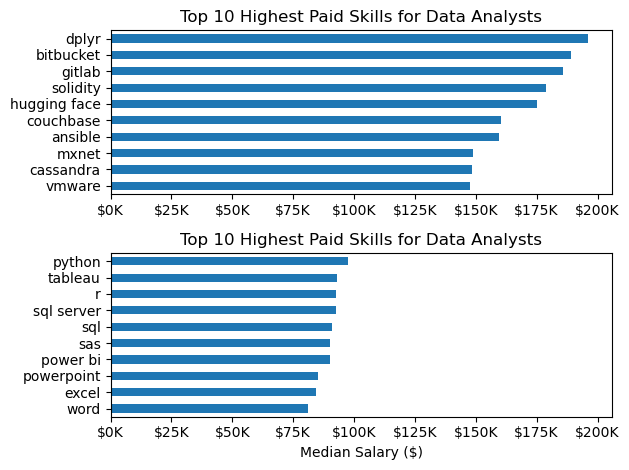

In [7]:
fig, ax = plt.subplots(2, 1)

df_top_pay[::-1].plot(
    kind='barh', 
    y='median_salary', 
    ax=ax[0], 
    legend=False
)
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(
    lambda  x, pos: f'${int(x/1000)}K'
))

df_top_skills_count[::-1].plot(
    kind='barh', 
    y='median_salary', 
    ax=ax[1], 
    legend=False
)
ax[1].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[1].set_xlabel('Median Salary ($)')
ax[1].set_ylabel('')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(
    lambda  x, pos: f'${int(x/1000)}K'
))

fig.tight_layout()
plt.show()

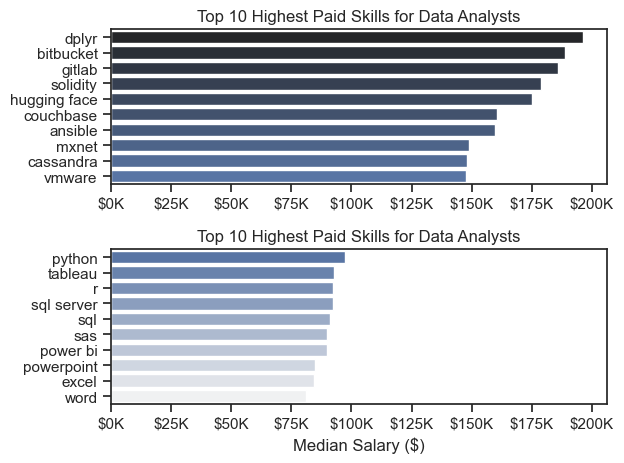

In [21]:
fig, ax = plt.subplots(2, 1)

sns.set_theme(style='ticks')

sns.barplot(
    data=df_top_pay, 
    x='median_salary', 
    y=df_top_pay.index, 
    ax=ax[0],
    palette='dark:b'
)
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(
    lambda  x, pos: f'${int(x/1000)}K'
))

sns.barplot(
    data=df_top_skills_count, 
    x='median_salary', 
    y=df_top_skills_count.index, 
    ax=ax[1],
    palette='light:b_r'
)
ax[1].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[1].set_xlabel('Median Salary ($)')
ax[1].set_ylabel('')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(
    lambda  x, pos: f'${int(x/1000)}K'
))

fig.tight_layout()
plt.show()

c:\Users\theim\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


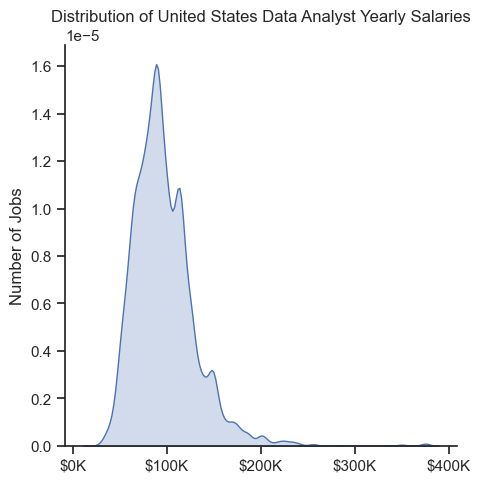

In [28]:
# Histogram
sns.displot(data=df_US_DA['salary_year_avg'], kind='kde', fill='True')
ax = plt.gca()
plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('')
plt.ylabel('Number of Jobs')
ax.xaxis.set_major_formatter(plt.FuncFormatter(
    lambda  x, pos: f'${int(x/1000)}K'
))

plt.show()

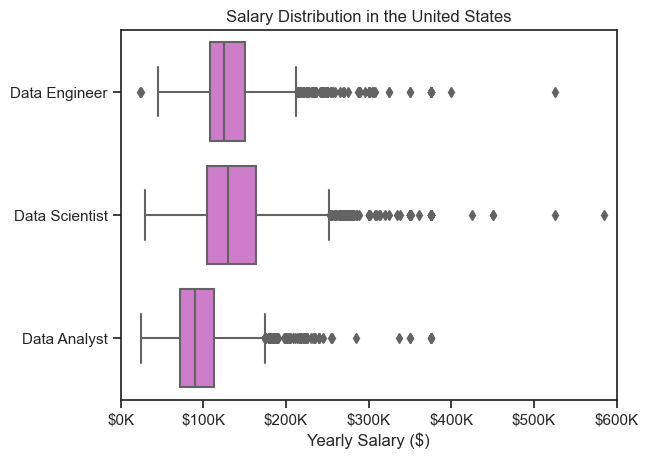

In [37]:
job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']

# Filter for only data jobs in US
df_US = df[
    (df['job_country'] == 'United States') & (df['job_title_short'].isin(job_titles))
].copy()

# Remove NaN salaries
df_US = df_US.dropna(subset=['salary_year_avg'])

job_list = [
    df_US[df_US['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles
]

sns.boxplot(
    data=df_US, 
    x='salary_year_avg', 
    y='job_title_short',
    color='orchid'
)
plt.title('Salary Distribution in the United States')
plt.ylabel('')
plt.xlabel('Yearly Salary ($)')
plt.xlim(0, 600000)
ax = plt.gca()
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda  x, pos: f'${int(x/1000)}K'
    )
)
plt.show()